In [1]:
import exoplanet

exoplanet.utils.docs_setup()
print(f"exoplanet.__version__ = '{exoplanet.__version__}'")

exoplanet.__version__ = '0.6.0'


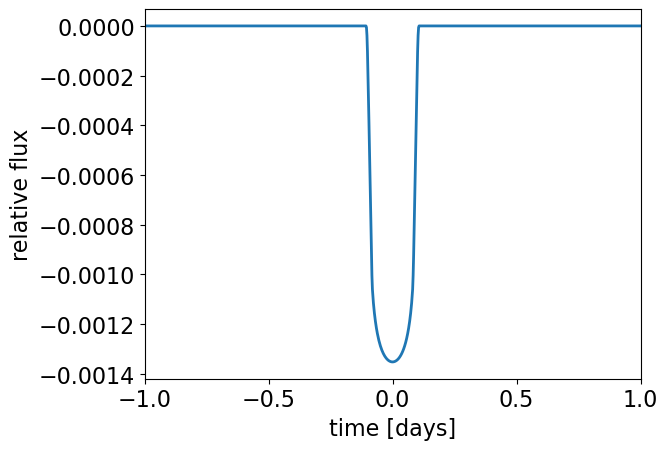

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import exoplanet as xo

# The light curve calculation requires an orbit
orbit = xo.orbits.KeplerianOrbit(period=18.801682, incl = 1.5585)

# Compute a limb-darkened light curve using starry
t = np.linspace(-1.0, 1.0, 1000)
u = [0.25508, 0.28185]
light_curve = (
    xo.LimbDarkLightCurve(*u)
    .get_light_curve(orbit=orbit, r=0.0346, t=t, texp=0.02)
    .eval()
)
# Note: the `eval` is needed because this is using Theano in
# the background

plt.plot(t, light_curve, color="C0", lw=2)
plt.ylabel("relative flux")
plt.xlabel("time [days]")
_ = plt.xlim(t.min(), t.max())

In [3]:
# The transit model in PyMC3
np.random.seed(123)
periods = np.random.uniform(5, 20, 2)
t0s = periods * np.random.rand(2)
t = np.arange(0, 80, 0.02)
yerr = 5e-4

In [6]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt

import exoplanet as xo
from starry import Star

np.random.seed(123)

# ------------------------------------------------------------
# 1. Simulate a fake 2-planet system
# ------------------------------------------------------------
periods = np.random.uniform(5, 20, 2)
t0s = periods * np.random.rand(2)

t = np.arange(0, 80, 0.02)
yerr = 5e-4

# Limb-darkened star (quadratic)
star = Star(udeg=2)

# ------------------------------------------------------------
# 2. Build the PyMC model
# ------------------------------------------------------------
with pm.Model() as model:

    # Baseline flux
    mean = pm.Normal("mean", mu=0.0, sigma=1.0)

    # Transit parameters
    t0 = pm.Normal("t0", mu=t0s, sigma=1.0, shape=2)

    logP = pm.Normal("logP", mu=np.log(periods), sigma=0.1, shape=2)
    period = pm.Deterministic("period", pt.exp(logP))

    # Kipping (2013) limb-darkening q1, q2
    q1 = pm.Uniform("q1", 0, 1)
    q2 = pm.Uniform("q2", 0, 1)
    u1, u2 = xo.QuadLimbDark().get_u(q1, q2)

    # Planet radii
    r = pm.Uniform("r", lower=0.01, upper=0.1, shape=2)

    # Impact parameters
    b = xo.ImpactParameter("b", ror=r, shape=2)

    # Keplerian orbit
    orbit = xo.orbits.KeplerianOrbit(period=period, t0=t0, b=b)

    # Compute light curves using starry
    light_curves = star.get_light_curve(orbit=orbit, r=r, t=t)
    light_curve = pm.Deterministic("light_curve", light_curves.sum(axis=-1) + mean)

    # ------------------------------------------------------------
    # 3. Generate synthetic data (only for tutorial)
    # ------------------------------------------------------------
    y = pm.draw(light_curve)
    y += yerr * np.random.randn(len(y))

    # Likelihood
    pm.Normal("obs", mu=light_curve, sigma=yerr, observed=y)

    # ------------------------------------------------------------
    # 4. Compute MAP estimate
    # ------------------------------------------------------------
    map_soln = pm.find_MAP()

map_soln


TypeError: Compiler.__init__() takes from 1 to 3 positional arguments but 4 were given